# Netflix Movies and TV Shows - Kaggle

# Importing Libraries


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset

In [48]:
df = pd.read_csv(r"C:\Users\gs602\OneDrive\Documents\Netflix Movies and TV Shows -Kaggle\netflix_titles.csv")
df


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [49]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [50]:
df.shape

(8807, 12)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [52]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [53]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

# Data Cleaning

In [54]:
df.drop_duplicates(inplace = True)

In [55]:
df['rating'] = df['rating'].fillna("Not Rated")
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")

In [56]:
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

In [57]:
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [109]:
df['date_added'] = df['date_added'].str.strip()

df['date_added'] = pd.to_datetime(df['date_added'])

In [110]:
df['year_added'] = df['date_added'].dt.year

In [58]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

# Data Visualization

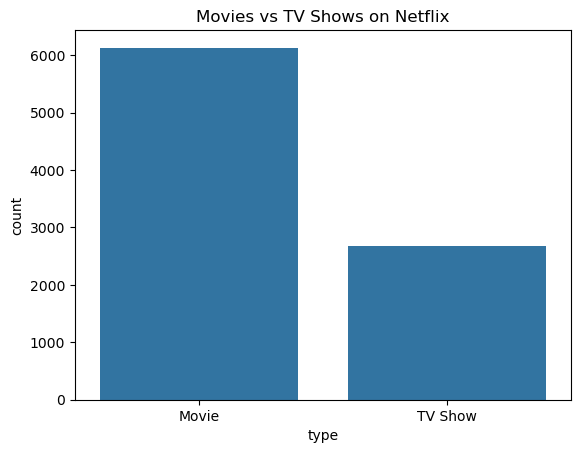

In [59]:
sns.countplot(x="type" , data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.show()

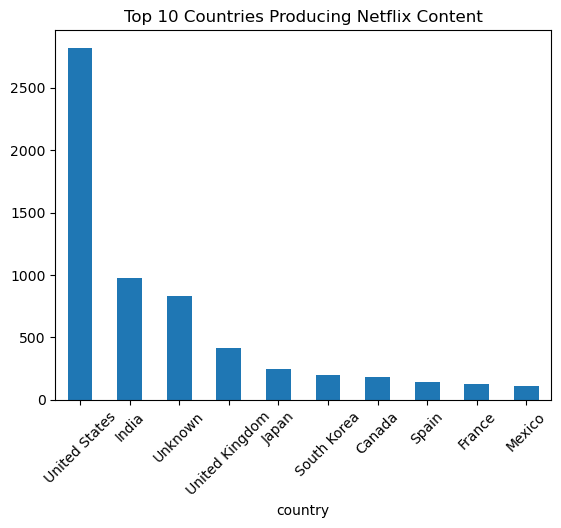

In [60]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xticks(rotation=45)
plt.show()

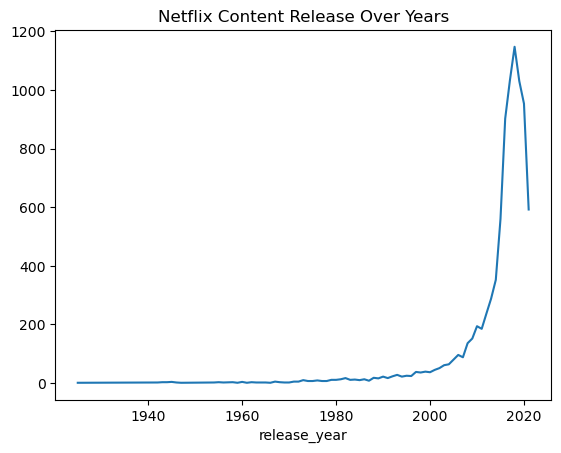

In [62]:
release_trend = df['release_year'].value_counts().sort_index()
release_trend.plot()
plt.title("Netflix Content Release Over Years")
plt.show()

In [64]:
release_trend.tail(10)

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

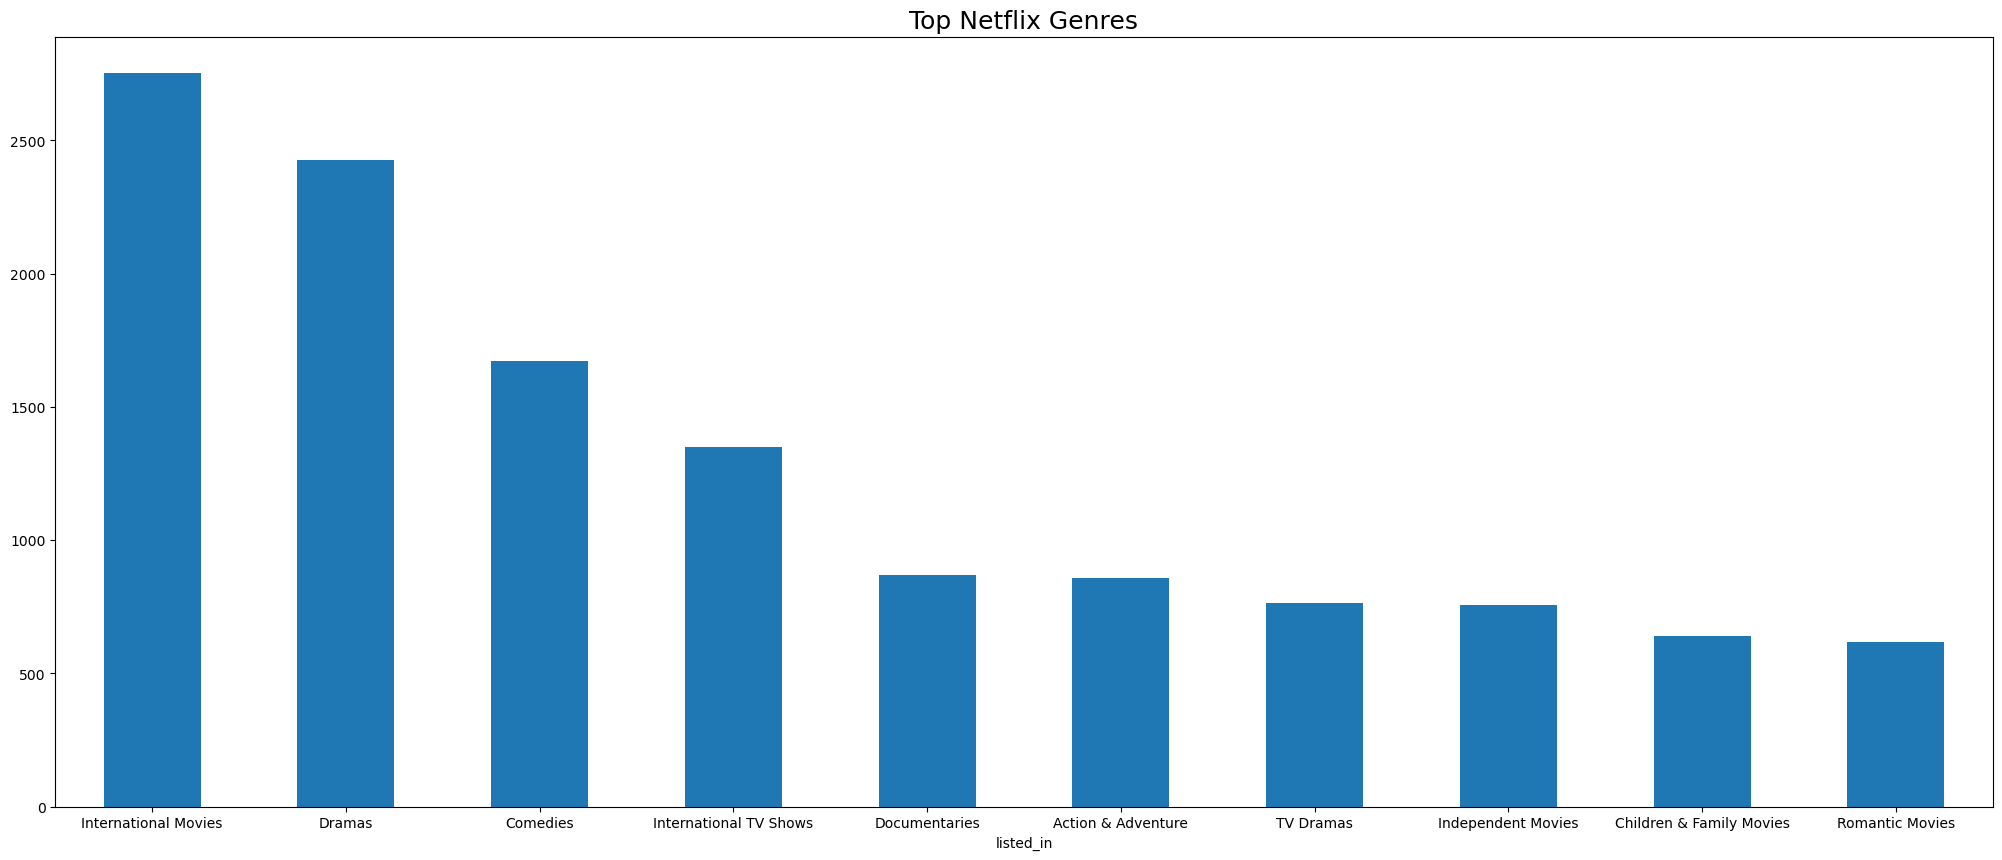

In [87]:
plt.figure(figsize=(25,10))
genres = df['listed_in'].str.split(', ').explode()
genres.value_counts().head(10).plot(kind="bar")
plt.title("Top Netflix Genres" , fontsize=18)
plt.xticks(rotation=360)
plt.show()

In [90]:
df = df[~df['rating'].str.contains('min', na=False)]

In [94]:
df = df[~df['rating'].isin(['UR','NC-17','Not Rated' , 'TV-Y7-FV'])]

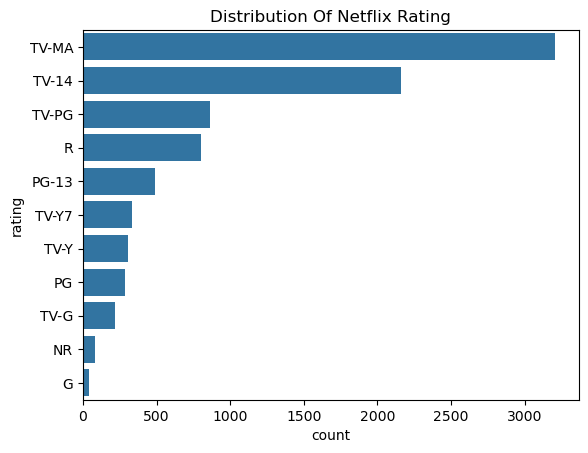

In [95]:
sns.countplot(y="rating" , data=df , order=df['rating'].value_counts().index)
plt.title("Distribution Of Netflix Rating")
plt.show()

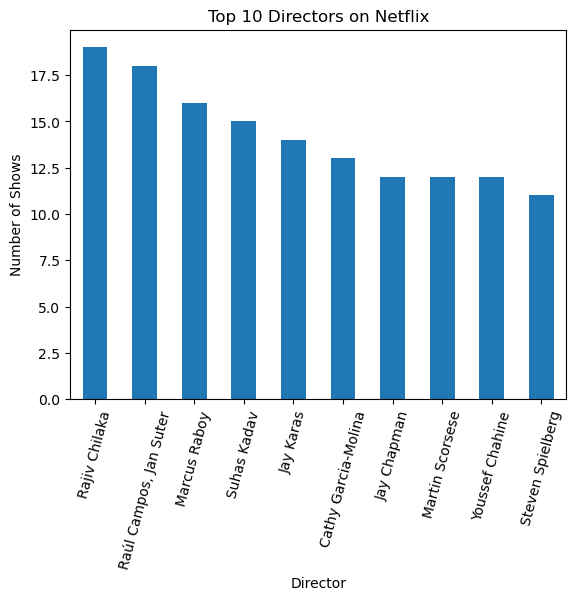

In [100]:
df_director = df[df['director'] != "Unknown"]

top_directors = df_director['director'].value_counts().head(10)
top_directors.plot(kind = "bar")
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Shows")
plt.xticks(rotation=75)

plt.show()

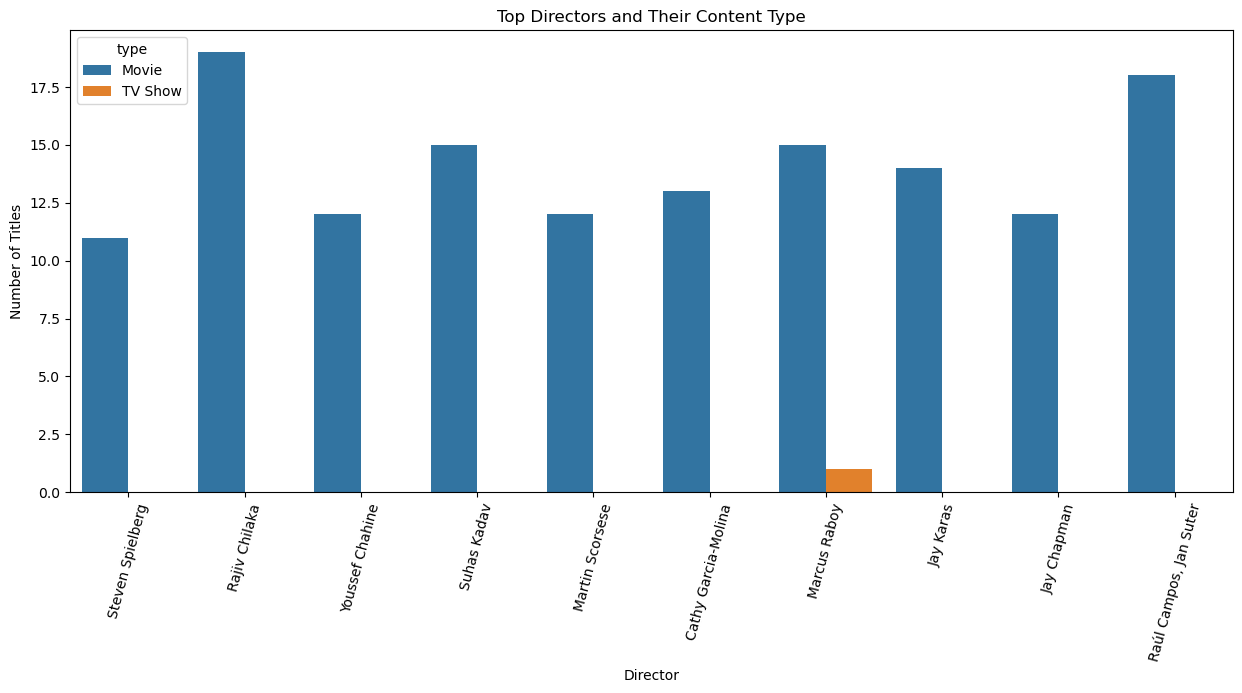

In [103]:
top10_names = top_directors.index

df_top = df_director[df_director['director'].isin(top10_names)]

plt.figure(figsize=(15,6))

sns.countplot(data=df_top, x='director', hue='type')

plt.title("Top Directors and Their Content Type")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.xticks(rotation=75)

plt.show()

# Importing ML Libraries

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Managing Data For Model Training

In [113]:
df_ml = df[['type','release_year','year_added','rating','country','duration']].copy()

In [114]:
df_ml['duration'] = df_ml['duration'].str.extract('(\d+)')
df_ml['duration'] = df_ml['duration'].astype(float)

le = LabelEncoder()

df_ml['type'] = le.fit_transform(df_ml['type'])

In [116]:
df_ml = pd.get_dummies(df_ml, columns=['rating','country'], drop_first=True)

In [117]:
X = df_ml.drop('type', axis=1)
y = df_ml['type']

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training ML Model

In [119]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [120]:
y_pred = model.predict(X_test)

# Model Evaluation

In [121]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9994311717861206


In [122]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1200
           1       1.00      1.00      1.00       558

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



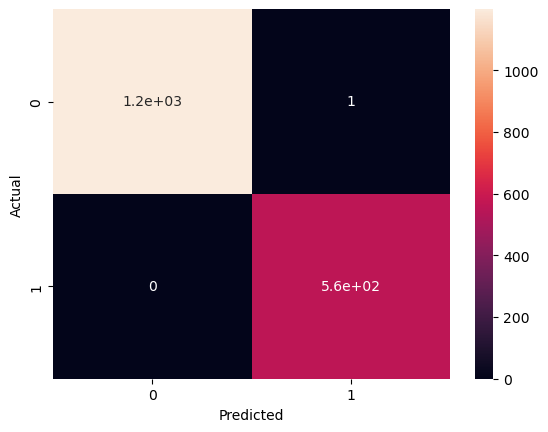

In [123]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()